In [276]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [277]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as rand
# import NSMap as ns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import src.NonstationarityTest as nt
import json

# %matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
filename = "../../datasets/baltic_sea_mesocosm_transformed.csv"

df = pd.read_csv(filename, encoding="utf-8", na_filter=False)
table = df.to_numpy()

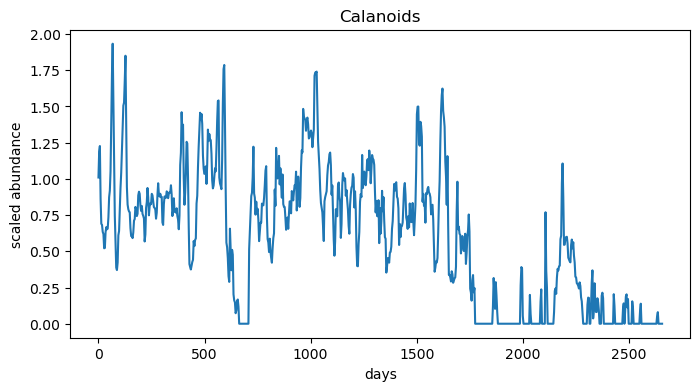

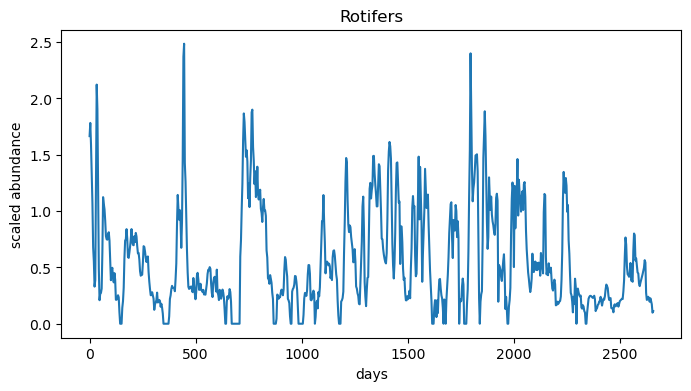

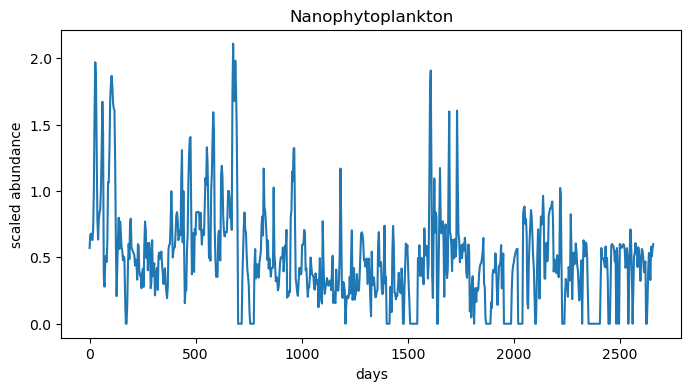

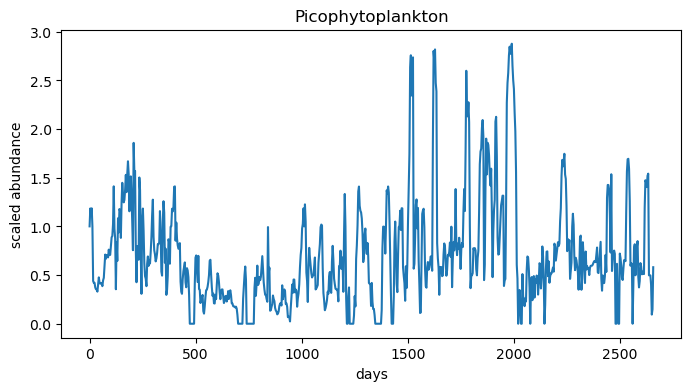

In [8]:
for i in range(4):
    fig, ax = plt.subplots(1,figsize=(8,4))
    ax.set_title(df.columns[i+1])
    ax.plot(table[:,0],table[:,i+1])
    ax.set_ylabel("scaled abundance")
    ax.set_xlabel("days")
    plt.show()

# Tau Determination
To determine the appropriate tau, a balance which maximizes forecast skill while minimizing autocorrelation must be found. We compute the optimal r^2 and autocorrelation for each lag, and find that tau=4 gives the best balance.

In [9]:
E_max = 6
taus = np.arange(1,7)
r_sqrd_table = np.zeros((len(taus),4))

In [10]:
""" uncomment to run for yourself
for i, series in enumerate(table.T[1:]):
    r_sqrds = [ns.get_delta_agg(series, E_max, tau=tau,
                             return_forecast_skill=True)[2] 
                   for tau in taus]
    r_sqrd_table[:,i] = r_sqrds
    
np.savetxt("../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")
"""

' uncomment to run for yourself\nfor i, series in enumerate(table.T[1:]):\n    r_sqrds = [ns.get_delta_agg(series, E_max, tau=tau,\n                             return_forecast_skill=True)[2] \n                   for tau in taus]\n    r_sqrd_table[:,i] = r_sqrds\n\nnp.savetxt("../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")\n'

In [11]:
# Check Autocorrelation

taus = np.arange(1,7)
autocorr_table = np.zeros((len(taus),4))

for i, series in enumerate(table.T[1:]):
    autocorr_table[:,i] = np.array([np.corrcoef(series[tau:],
                                                series[:-tau])[0,1]
                                  for tau in taus])

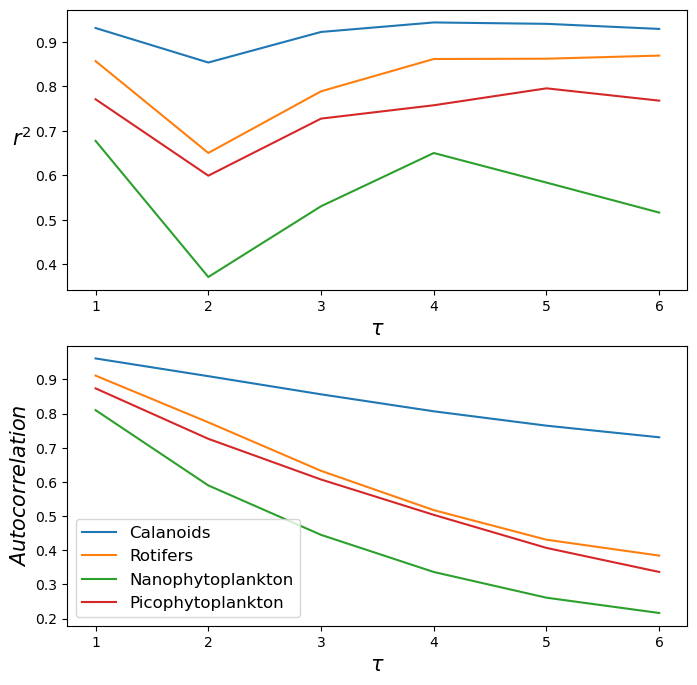

In [12]:
r_sqrd_table = np.loadtxt("../../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", delimiter=",")

fig, ax = plt.subplots(2,figsize=(8,8))
for i in range(4):
    ax[0].plot(taus, r_sqrd_table[:,i], label=df.columns[i+1])
    
for i in range(4):
    ax[1].plot(taus, autocorr_table[:,i], label=df.columns[i+1])

ax[0].set_ylabel(r"$r^2$", fontsize = 15, rotation = 0, labelpad=10)
ax[0].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)

ax[1].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)
ax[1].set_ylabel(r"$Auto correlation$", fontsize = 15, rotation = 90)

plt.legend(fontsize = 12)

# Effect of Time Window on Baltic Sea Species
Now we systematically evaluate the nonstationarity of subseries of each Baltic Sea series.

In [239]:
year_steps = 27
maxLen = table[:,0].shape[0]
lengths = np.arange(year_steps*4,maxLen+1,step=year_steps)

In [240]:
# Standardize function (assumes mean/std normalization)
def standardize(ts):
    return (ts - np.mean(ts)) / np.std(ts)

In [241]:
# Load parameters from JSON file
def load_params(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

params = load_params("baltic_sea_mesocosm_params.json")

In [242]:
E_range = params["E_range"]
lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]
N_replicates = params["N_replicates"]
resolution = params["resolution"]
theta_range = params["theta_range"]
delta_range = params["delta_range"]

In [255]:
## Compute delta for each subseries, uncomment if you wish to run again

i = 4
species = df.columns[1:][i]

# for i, species in enumerate(df.columns[1:].to_numpy()):
ts = standardize(table[:,i])

E = 5
tau = 1
h = 0

# length, starting index, delta, theta, r_sqrd
n_rows = 351
results = np.zeros((n_rows, 5))
tally = 0

length = lengths[-1]
start = 0

# for length in lengths:
#     for start in np.arange(0, maxLen - length+1, step=year_steps):

ts_chunk = ts[start:length+start]
t = np.linspace(0, 1, length)

data = (ts_chunk, t, tau)
# plotTS(ts_chunk)

IndexError: index 4 is out of bounds for axis 0 with size 4

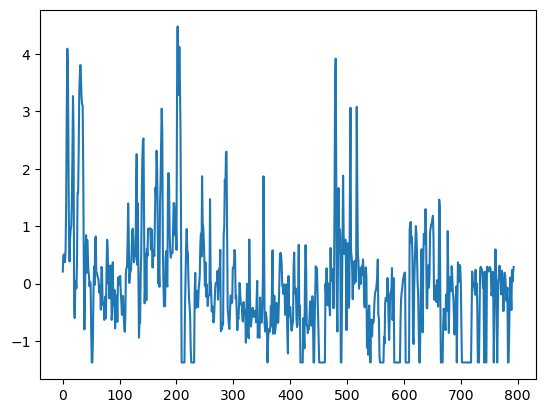

In [257]:
plt.plot(ts)

In [ ]:
evidence, significance_level, bayes_factor_error = nt.nonstationarity_test(
        data,
        theta_range=params["theta_range"],
        delta_range=params["delta_range"],
        E_range=params["E_range"],
        lambda1=params["lambda1"],
        lambda2=params["lambda2"],
        p=params["p"],
        resolution=params["resolution"]
)
results[tally] = np.array([length, start, evidence, significance_level, bayes_factor_error])

In [ ]:
print(f"evidence = {evidence}")

In [279]:
E = 5
tau = 1
data_E = (standardize(ts_chunk), t, E, tau)

resolution = 10
theta_range = [0, 1e2]

posterior_grid, theta_values, delta_values = nt.posterior_grid_evaluation(data_E, theta_range, delta_range, lambda1, lambda2)

0.33717886468628777
-681.0360444297211
0.33259215308394124
-675.7080781284727
0.33271802487055596
-675.8552700013759
0.3332592247571516
-676.4875042176235
0.33386487749101806
-677.1938165136633
0.3345062761409584
-677.940420103785
0.3351549324553172
-678.6940172420453
0.3357855045966291
-679.4252077371938
0.3363809283665524
-680.1143820122687
0.33693157977246185
-680.7506495464826
3.6336369046391455
-1605.8352238212128
4.399868243036187
-1680.266696564954
4.986053281499002
-1728.9189559555105
5.470841628073913
-1765.0134085486059
5.882003638957548
-1793.2022903031348
6.243401705730018
-1816.397473461412
6.573131277058643
-1836.4174137993887
6.885270975651211
-1854.4647449761223
7.188445721551548
-1871.2269445432958
7.481643625926702
-1886.7782028637191
19.24996168543627
-2254.4052072051677
18.779199884099043
-2244.7738775599037
18.106463546515613
-2230.582810708644
18.4528977773743
-2237.9553109246094
19.42764655317898
-2257.9793630517543
20.604261033589836
-2280.852862204197
21.830054

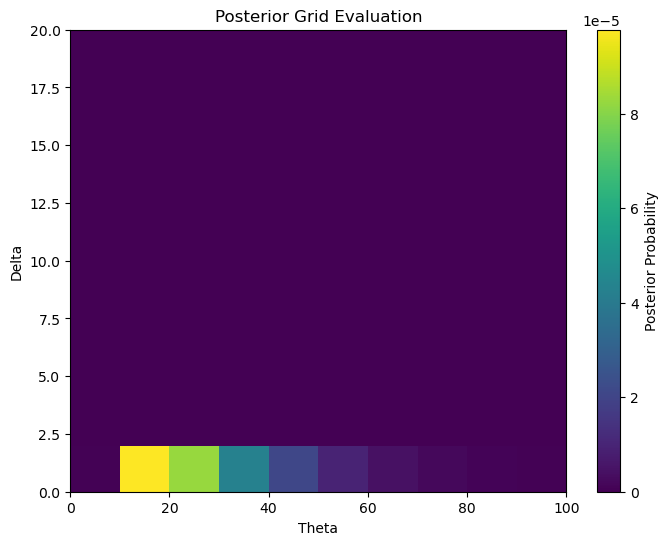

In [280]:
# Plot posterior_grid evaluations for a given time series chunk
import matplotlib.pyplot as plt

def plot_posterior_grid(posterior_grid, theta_values, delta_values):
    plt.figure(figsize=(8, 6))
    plt.imshow(posterior_grid, aspect='auto', origin='lower',
               extent=[theta_values[0], theta_values[-1], delta_values[0], delta_values[-1]],
               cmap='viridis')
    plt.colorbar(label='Posterior Probability')
    plt.xlabel('Theta')
    plt.ylabel('Delta')
    plt.title('Posterior Grid Evaluation')
    plt.show()

# Example usage (replace with actual variables from your workflow):
plot_posterior_grid(posterior_grid, theta_values, delta_values)

In [266]:
Xr = standardize(ts_chunk)

Xemb, Y, tx = ns.delayEmbed(Xr, E, tau, t=t)

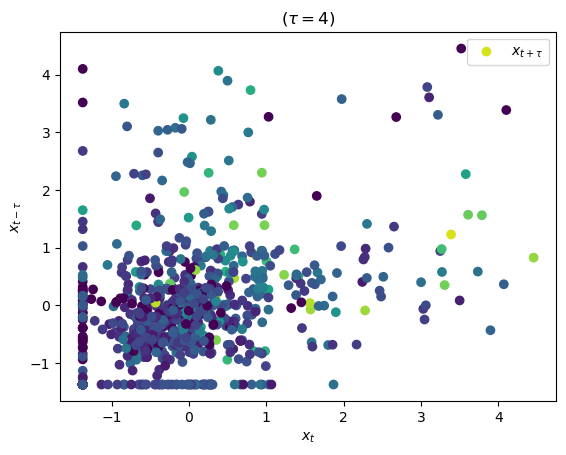

In [267]:
plt.title(r"($\tau = 4$)")
plt.scatter(Xemb[:,0], Xemb[:,1], c=Y.flatten(), label=r"$x_{t+\tau}$")
plt.xlabel(r'$x_t$')
plt.ylabel(r'$x_{t-\tau}$')
plt.legend()

In [227]:
nt.posterior_2d(1e0, 0, data_E, lambda1, lambda2)

array([[1.53198062e-42]])

In [231]:
import src.NonstationarityTest as nt
import src.NSMap as ns

In [15]:
# Convert the delta values for each subseries into a square matrix
# which is plotted using matplotlib's imshow.
def makeHeatMapBaltic(results):
    nonstationarityHeatMap = np.zeros((29,29)) * np.nan
    for l, o, d, t, r in results:
        i_length = 27-(int(l / year_steps) - 2)
        i_offset = int(o / year_steps)
        # print(i_length, i_offset)
        nonstationarityHeatMap[i_length, i_offset] = d
        
    return nonstationarityHeatMap

In [16]:
# Make the figure
def makeFigureBaltic(nonstationarityHeatMap, ts, name, ax):
    name_to_fig_title = {"Rotifers" : "Figure_S9",
                         "Nanophytoplankton": "Figure_S10",
                         "Picophytoplankton": "Figure_S11"}
    
    scaling = lengths[-1] *3.35 / 365
    
    # im = ax.imshow(np.zeros(nonstationarityHeatMap[:-2].shape), cmap=cm.Greys)
    im = ax.imshow(np.log(nonstationarityHeatMap[:-2]+1), cmap=custom_cmap)
    ax.set_xticks(np.arange(31,step = 30 / scaling))
    ax.set_yticks(30-365*np.arange(1,8)/3.35/26)
    ax.set_xticklabels([])
    ax.set_yticklabels(np.arange(1,8))
    ax.set_ylim(27,-1)
    ax.set_xlim(-1.3,32)
    
    ax.set_ylabel("Time series length (years)",fontsize=15)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(r"$\log(\overline{\delta}+1)$",fontsize=15)

    axTS = divider.append_axes('bottom', size='30%', pad=0.1)

    axTS.plot(table[:,0]/365, ts,c="dodgerblue")
    axTS.set_ylabel(name,fontsize=12)
    axTS.set_xlabel("Start year",fontsize=15)
    axTS.set_yticks([])
    
    plt.savefig(f"../figures_eps/baltic_sea_multiwindow/{name_to_fig_title[name]}.eps", format="eps", bbox_inches="tight", transparent=False, facecolor="white")
    plt.show()

In [17]:
# Make a custom orange to blue color scheme
orange_rgba = colors.to_rgba("orange")
dodgerblue_rgba = colors.to_rgba("dodgerblue")
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [dodgerblue_rgba, orange_rgba]) 
custom_cmap.set_bad("white", 1)

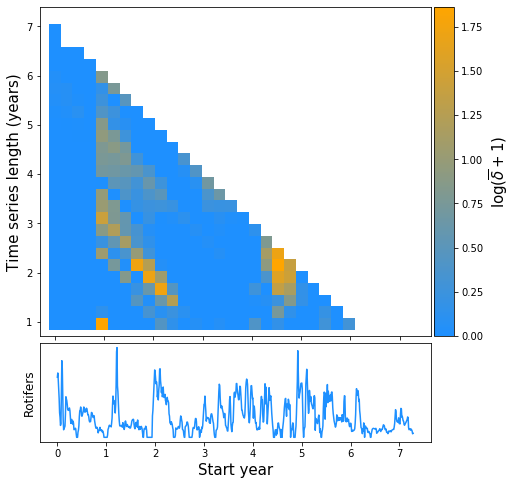

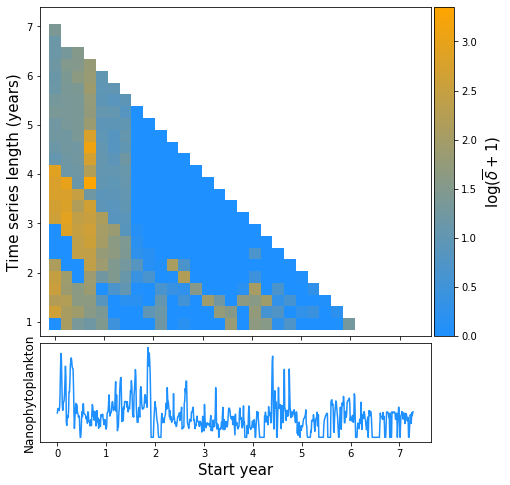

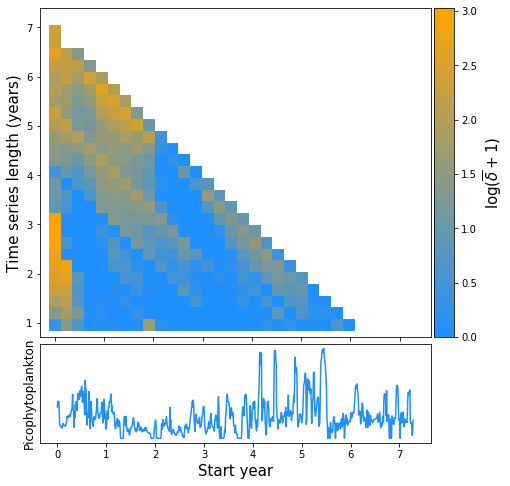

In [14]:
# Produce the figures
indices = [1,2,3]
year_steps = 27

for index in indices:
    figb, axb = plt.subplots(1, figsize=(8,8))
    
    species_list = ["Calanoids","Rotifers","Nanophytoplankton",
                    "Picophytoplankton"]
    results = np.loadtxt(f"../results/baltic_sea_multiwindow/{species_list[index]}_time_window.csv",
                         delimiter=",")
    lengths = np.unique(results[:,0])
    
    ts = ns.standardize(table[:,index+1])
    nonstationarityHeatMap = makeHeatMapBaltic(results)
    makeFigureBaltic(nonstationarityHeatMap, ts, species_list[index], axb)

In [71]:
# Check the type of the time series chunk
print('Type of ts_chunk:', type(ts_chunk))
print('Shape of ts_chunk:', getattr(ts_chunk, 'shape', 'No shape attribute'))

Type of ts_chunk: <class 'numpy.ndarray'>
Shape of ts_chunk: (783, 1)
